# 导入依赖和数据

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
# InteractiveShell.ast_node_interactivity = "all"

In [2]:
# 加载数据
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

# 数据概况

In [3]:
# 查看前3行
print("\n训练集前3行:")
print(train.head(3))

# 查看数据概况
print("\n训练集信息:")
print(f"行数: {train.shape[0]}, 列数: {train.shape[1]}")


训练集前3行:
  PassengerId HomePlanet CryoSleep  Cabin  Destination   Age    VIP  \
0     0001_01     Europa     False  B/0/P  TRAPPIST-1e  39.0  False   
1     0002_01      Earth     False  F/0/S  TRAPPIST-1e  24.0  False   
2     0003_01     Europa     False  A/0/S  TRAPPIST-1e  58.0   True   

   RoomService  FoodCourt  ShoppingMall     Spa  VRDeck             Name  \
0          0.0        0.0           0.0     0.0     0.0  Maham Ofracculy   
1        109.0        9.0          25.0   549.0    44.0     Juanna Vines   
2         43.0     3576.0           0.0  6715.0    49.0    Altark Susent   

   Transported  
0        False  
1         True  
2        False  

训练集信息:
行数: 8693, 列数: 14


In [4]:
print('训练集缺失值:')
print(train.isna().sum())
print('')
print('测试集缺失集:')
print(test.isna().sum())

训练集缺失值:
PassengerId       0
HomePlanet      201
CryoSleep       217
Cabin           199
Destination     182
Age             179
VIP             203
RoomService     181
FoodCourt       183
ShoppingMall    208
Spa             183
VRDeck          188
Name            200
Transported       0
dtype: int64

测试集缺失集:
PassengerId       0
HomePlanet       87
CryoSleep        93
Cabin           100
Destination      92
Age              91
VIP              93
RoomService      82
FoodCourt       106
ShoppingMall     98
Spa             101
VRDeck           80
Name             94
dtype: int64


# 初步探索

Text(0.5, 1.0, 'Target distribution')

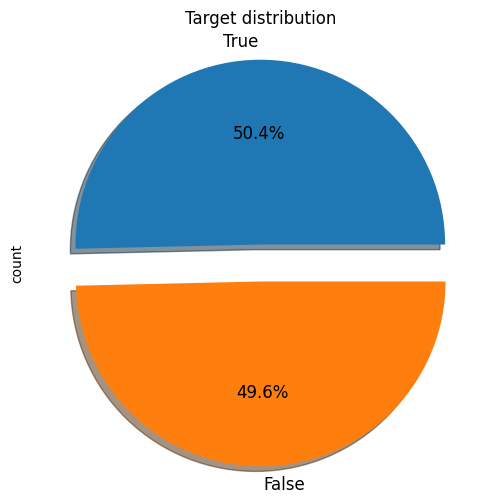

In [5]:
# Figure size
plt.figure(figsize=(6, 6))

# transported分布饼图
train['Transported'].value_counts().plot.pie(explode=[0.1, 0.1], autopct='%1.1f%%', shadow=True,
                                             textprops={'fontsize': 12}).set_title("Target distribution")

Text(0.5, 0, 'Age (years)')

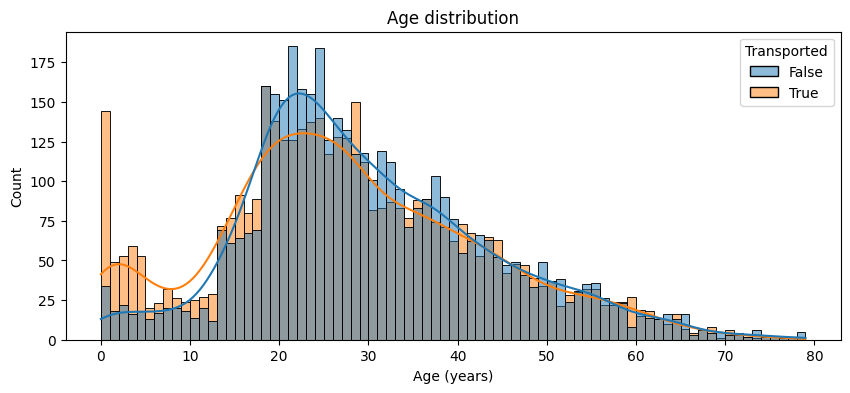

In [6]:
# Figure size
plt.figure(figsize=(10, 4))

# 年龄分布直方图
sns.histplot(data=train, x='Age', hue='Transported', binwidth=1, kde=True)
plt.title('Age distribution')
plt.xlabel('Age (years)')

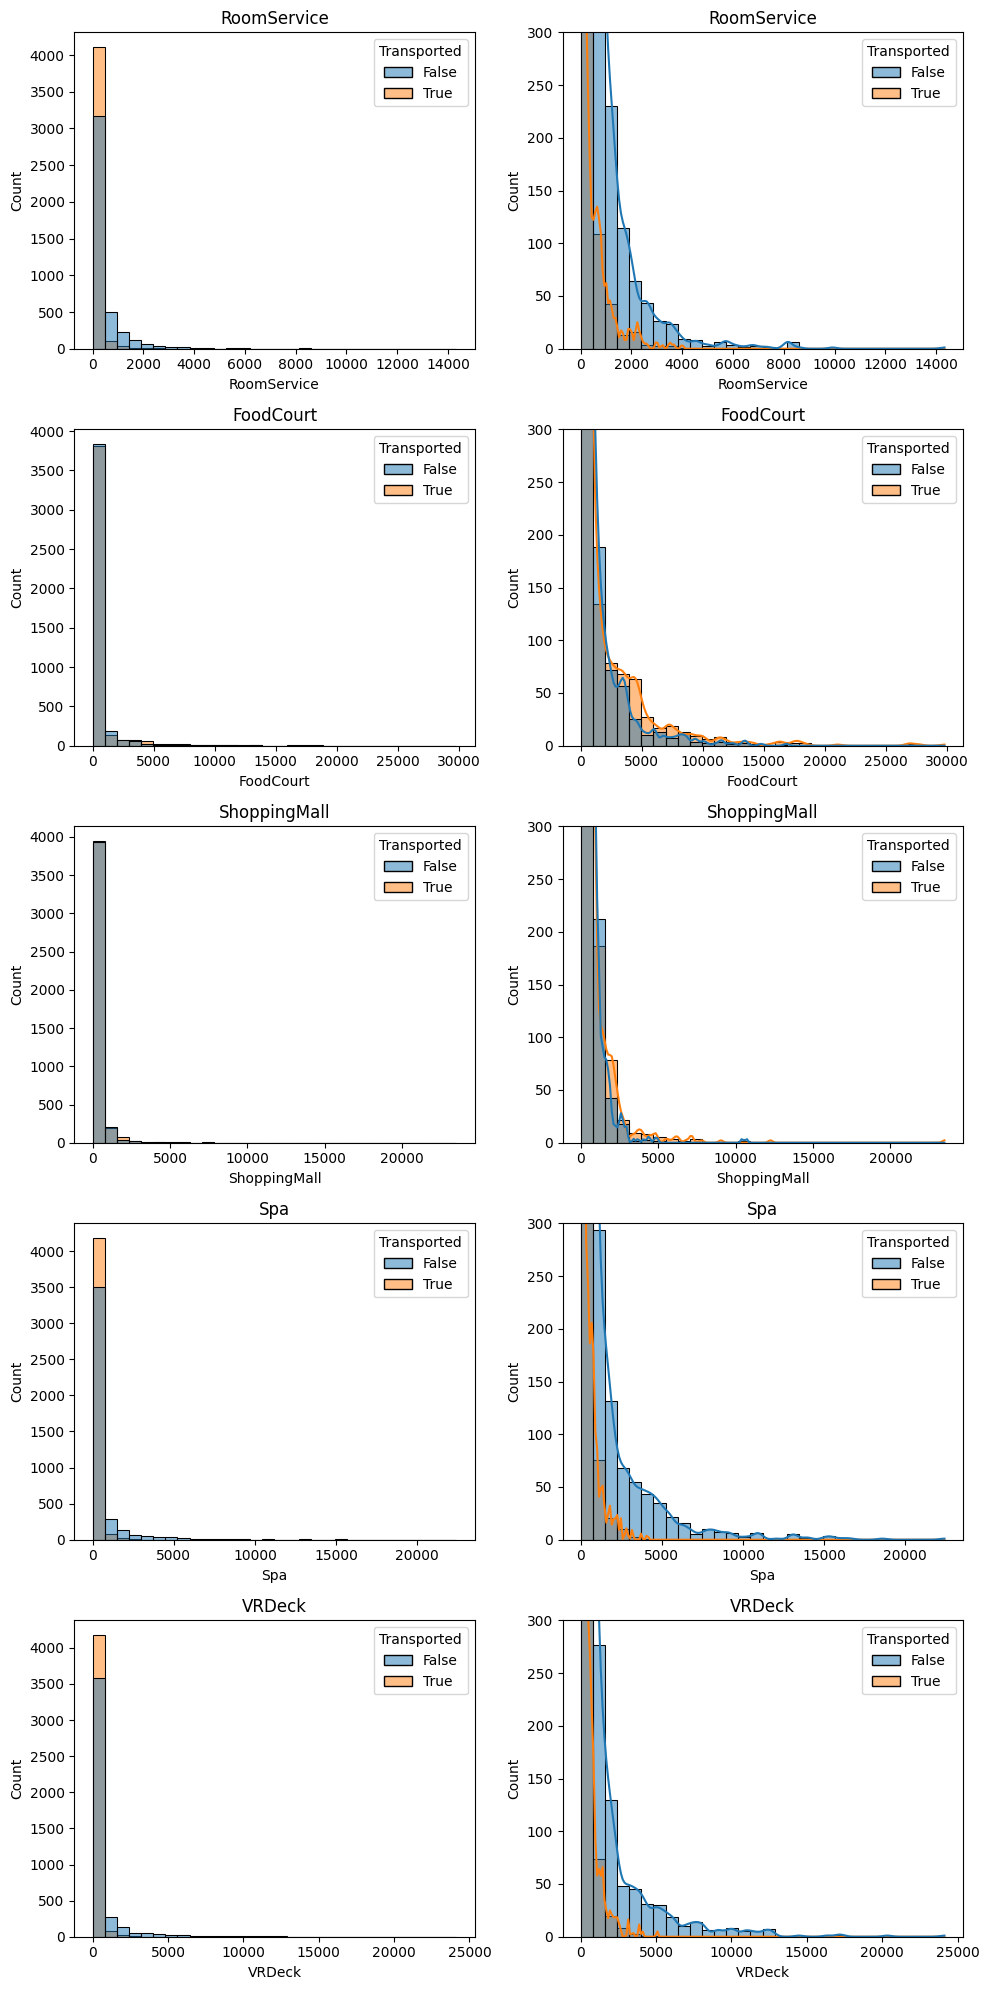

In [7]:
# 各消费字段分析
exp_feats = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']

# Plot expenditure features
fig = plt.figure(figsize=(10, 20))
for i, var_name in enumerate(exp_feats):
    #左边单纯统计频数
    ax = fig.add_subplot(5, 2, 2 * i + 1)
    sns.histplot(data=train, x=var_name, axes=ax, bins=30, kde=False, hue='Transported')
    ax.set_title(var_name)

    # 右边加上核密度曲线
    ax = fig.add_subplot(5, 2, 2 * i + 2)
    sns.histplot(data=train, x=var_name, axes=ax, bins=30, kde=True, hue='Transported')
    plt.ylim([0, 300])  #限制y轴高度，方便观察核密度估计曲线
    ax.set_title(var_name)
fig.tight_layout()  # Improves appearance a bit
plt.show()

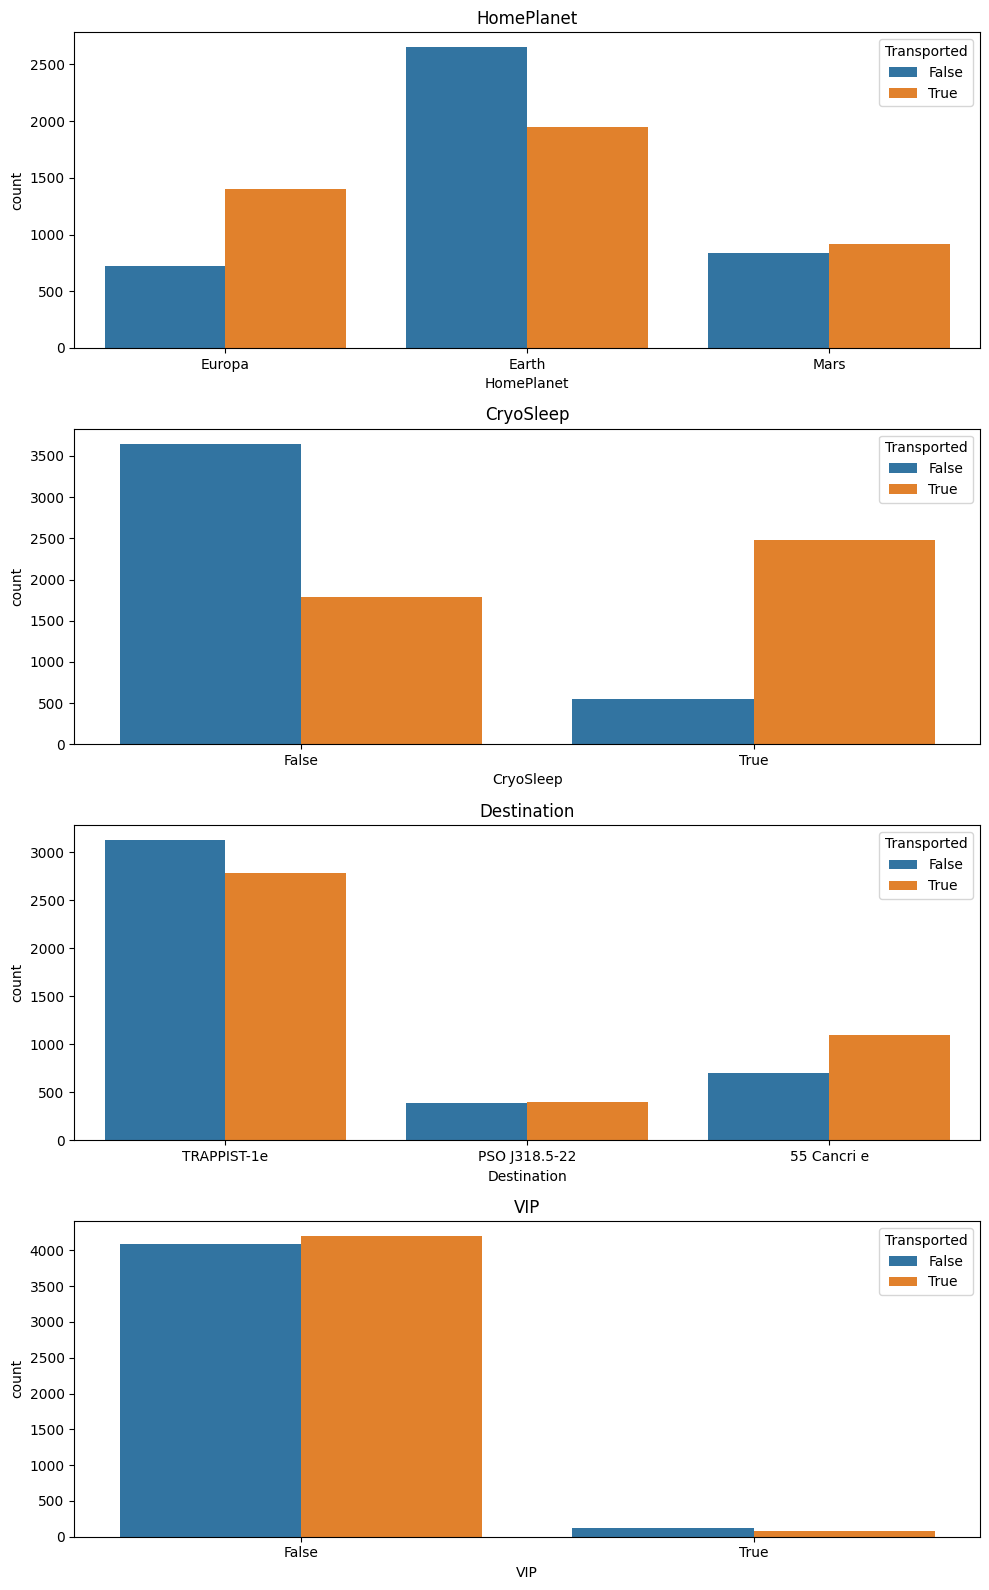

In [8]:
# 名义类特征
cat_feats = ['HomePlanet', 'CryoSleep', 'Destination', 'VIP']

# 直方图统计频数
fig = plt.figure(figsize=(10, 16))
for i, var_name in enumerate(cat_feats):
    ax = fig.add_subplot(4, 1, i + 1)
    sns.countplot(data=train, x=var_name, axes=ax, hue='Transported')
    ax.set_title(var_name)
fig.tight_layout()  # Improves appearance a bit
plt.show()


缺失值分析

# 进一步探索

## 1. 消费

是否消费越多，越容易被传走？或者没有消费的更容易被传走

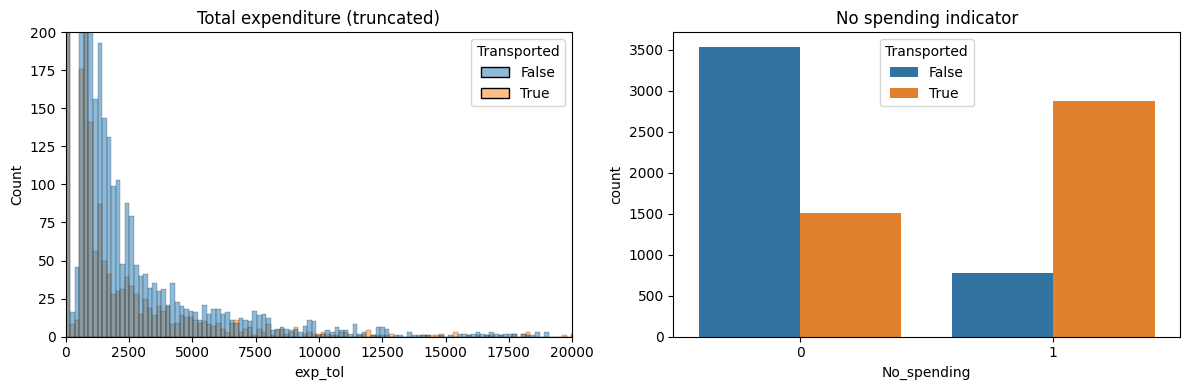

In [9]:
#新增字段“总消费”
train['exp_tol'] = train[exp_feats].sum(axis=1)
test['exp_tol'] = test[exp_feats].sum(axis=1)

fig = plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
sns.histplot(data=train, x='exp_tol', hue='Transported', bins=200)
plt.title('Total expenditure (truncated)')
plt.ylim([0, 200])
plt.xlim([0, 20000])

#新增字段是否消费
train['No_spending'] = (train['exp_tol'] == 0).astype(int)
test['No_spending'] = (test['exp_tol'] == 0).astype(int)

plt.subplot(1, 2, 2)
sns.countplot(data=train, x='No_spending', hue='Transported')
plt.title('No spending indicator')
fig.tight_layout()

## 2. 乘客分组

观察乘客id，可以发现前四位是组号，后两位是组内编号.会不会是特定组别更容易被传走

d:\python\Lib\site-packages\IPython\core\events.py:82: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)
d:\python\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


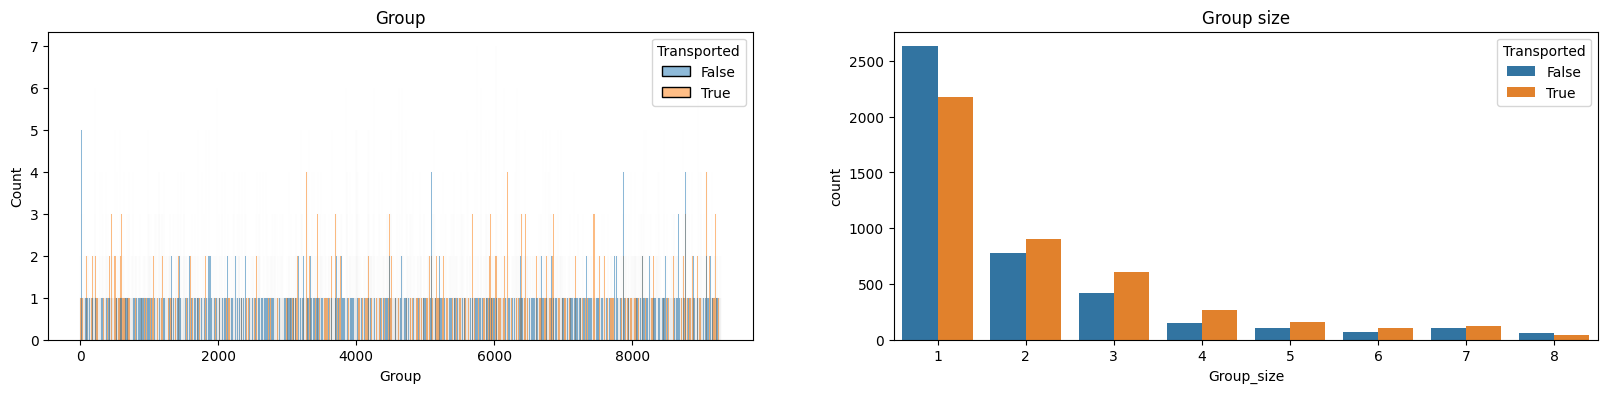

In [10]:
# 新增特征 组别
train['Group'] = train['PassengerId'].apply(lambda x: x.split('_')[0]).astype(int)
test['Group'] = test['PassengerId'].apply(lambda x: x.split('_')[0]).astype(int)

# 新增特征 组的人数
train['Group_size'] = train['Group'].map(lambda x: pd.concat([train['Group'], test['Group']]).value_counts()[x])
test['Group_size'] = test['Group'].map(lambda x: pd.concat([train['Group'], test['Group']]).value_counts()[x])

plt.figure(figsize=(20, 4))
plt.subplot(1, 2, 1)
sns.histplot(data=train, x='Group', hue='Transported', binwidth=1)
plt.title('Group')

plt.subplot(1, 2, 2)
sns.countplot(data=train, x='Group_size', hue='Transported')
plt.title('Group size')
fig.tight_layout()

#运行过慢

(0.0, 3000.0)

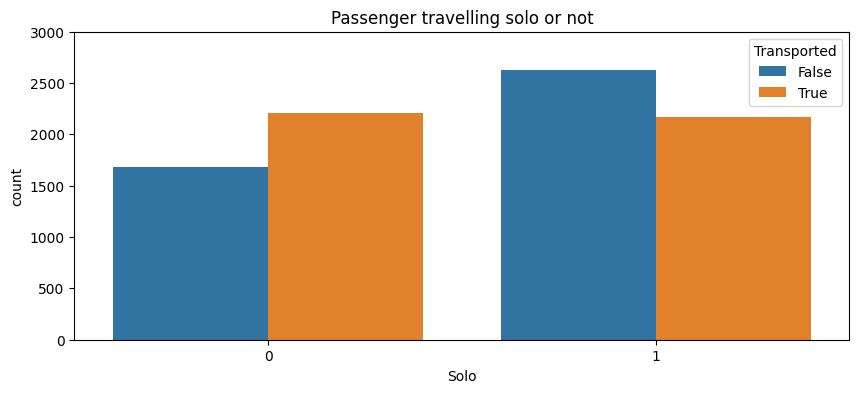

In [11]:
# 是否单人间
train['Solo'] = (train['Group_size'] == 1).astype(int)
test['Solo'] = (test['Group_size'] == 1).astype(int)

# New feature distribution
plt.figure(figsize=(10, 4))
sns.countplot(data=train, x='Solo', hue='Transported')
plt.title('Passenger travelling solo or not')
plt.ylim([0, 3000])

## 3. 舱室

In [12]:
decks = train['Cabin'].dropna().apply(lambda x: x.split('/')[0])
decks.value_counts()

Cabin
F    2794
G    2559
E     876
B     779
C     747
D     478
A     256
T       5
Name: count, dtype: int64

将cabin拆分为三个字段：甲板、舱室号和舷侧

In [13]:
train['Cabin_deck'] = train['Cabin'].apply(lambda x: x.split('/')[0] if not pd.isna(x) else None)
train['Cabin_number'] = train['Cabin'].apply(lambda x: int(x.split('/')[1]) if not pd.isna(x) else None)
train['Cabin_side'] = train['Cabin'].apply(lambda x: x.split('/')[2] if not pd.isna(x) else None)

test['Cabin_deck'] = test['Cabin'].apply(lambda x: x.split('/')[0] if not pd.isna(x) else None)
test['Cabin_number'] = test['Cabin'].apply(lambda x: int(x.split('/')[1]) if not pd.isna(x) else None)
test['Cabin_side'] = test['Cabin'].apply(lambda x: x.split('/')[2] if not pd.isna(x) else None)

画出舱室号分布

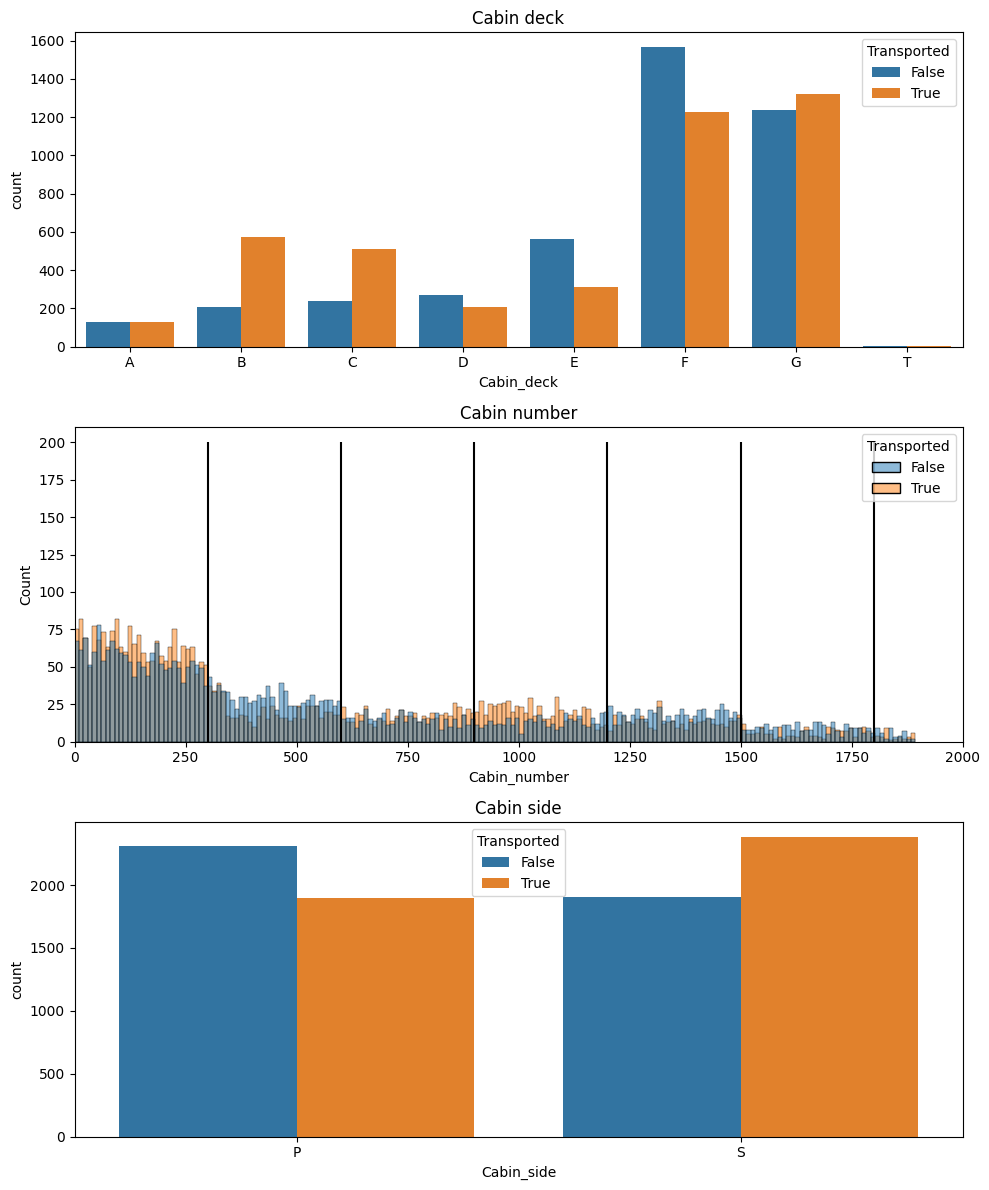

In [14]:
fig = plt.figure(figsize=(10, 12))
plt.subplot(3, 1, 1)
sns.countplot(data=train, x='Cabin_deck', hue='Transported', order=['A', 'B', 'C', 'D', 'E', 'F', 'G', 'T'])
plt.title('Cabin deck')

plt.subplot(3, 1, 2)
sns.histplot(data=train, x='Cabin_number', hue='Transported', binwidth=10)
plt.vlines(300, ymin=0, ymax=200, color='black')
plt.vlines(600, ymin=0, ymax=200, color='black')
plt.vlines(900, ymin=0, ymax=200, color='black')
plt.vlines(1200, ymin=0, ymax=200, color='black')
plt.vlines(1500, ymin=0, ymax=200, color='black')
plt.vlines(1800, ymin=0, ymax=200, color='black')
plt.title('Cabin number')
plt.xlim([0, 2000])

plt.subplot(3, 1, 3)
sns.countplot(data=train, x='Cabin_side', hue='Transported')
plt.title('Cabin side')
fig.tight_layout()

从第二个图看出300个舱室一组，进行分箱

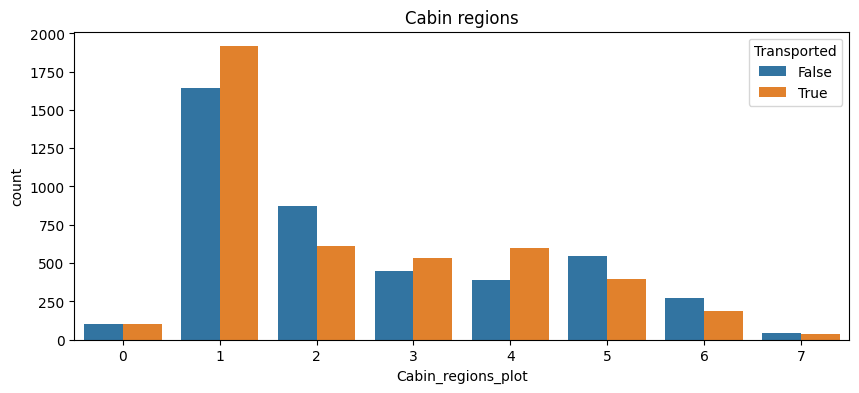

In [15]:
# 舱室分箱
train['Cabin_region1'] = (train['Cabin_number'] < 300).astype(int)
train['Cabin_region2'] = ((train['Cabin_number'] >= 300) & (train['Cabin_number'] < 600)).astype(int)
train['Cabin_region3'] = ((train['Cabin_number'] >= 600) & (train['Cabin_number'] < 900)).astype(int)
train['Cabin_region4'] = ((train['Cabin_number'] >= 900) & (train['Cabin_number'] < 1200)).astype(int)
train['Cabin_region5'] = ((train['Cabin_number'] >= 1200) & (train['Cabin_number'] < 1500)).astype(int)
train['Cabin_region6'] = ((train['Cabin_number'] >= 1500) & (train['Cabin_number'] < 1800)).astype(int)
train['Cabin_region7'] = (train['Cabin_number'] >= 1800).astype(int)


test['Cabin_region1'] = (test['Cabin_number'] < 300).astype(int)
test['Cabin_region2'] = ((test['Cabin_number'] >= 300) & (test['Cabin_number'] < 600)).astype(int)
test['Cabin_region3'] = ((test['Cabin_number'] >= 600) & (test['Cabin_number'] < 900)).astype(int)
test['Cabin_region4'] = ((test['Cabin_number'] >= 900) & (test['Cabin_number'] < 1200)).astype(int)
test['Cabin_region5'] = ((test['Cabin_number'] >= 1200) & (test['Cabin_number'] < 1500)).astype(int)
test['Cabin_region6'] = ((test['Cabin_number'] >= 1500) & (test['Cabin_number'] < 1800)).astype(int)
test['Cabin_region7'] = (test['Cabin_number'] >= 1800).astype(int)

# 画出分布
plt.figure(figsize=(10, 4))
train['Cabin_regions_plot'] = (
            train['Cabin_region1'] + 2 * train['Cabin_region2'] + 3 * train['Cabin_region3'] + 4 * train[
        'Cabin_region4'] + 5 * train['Cabin_region5'] + 6 * train['Cabin_region6'] + 7 * train['Cabin_region7']).astype(
    int)
sns.countplot(data=train, x='Cabin_regions_plot', hue='Transported')
plt.title('Cabin regions')
train.drop('Cabin_regions_plot', axis=1, inplace=True)

## 4. 家庭

Text(0.5, 1.0, 'Family size')

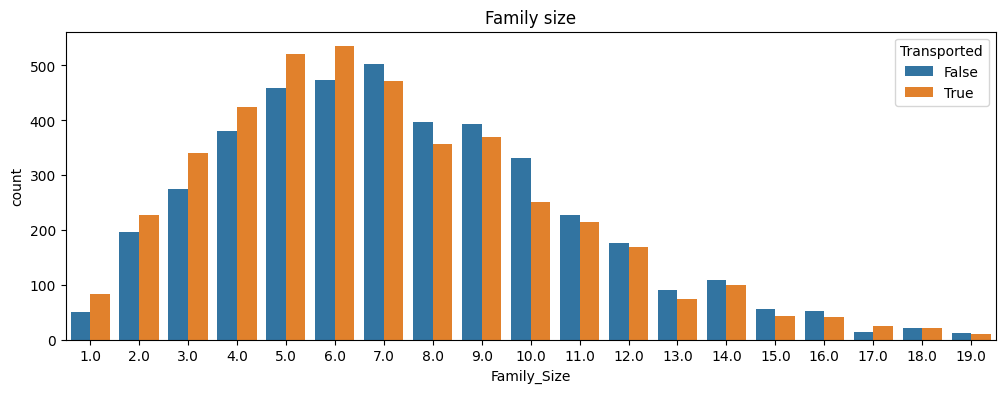

In [16]:
# 将缺失值先替换成“未知”
train['Name'].fillna('Unknown Unknown')
test['Name'].fillna('Unknown Unknown')

# 新特征 - 姓氏
train['Surname'] = train['Name'].str.split().str[-1]
test['Surname'] = test['Name'].str.split().str[-1]
# 新特征 - 家庭人数
train.loc[train['Surname'] == 'Unknown', 'Surname'] = np.nan
test.loc[test['Surname'] == 'Unknown', 'Surname'] = np.nan

surname_count = train['Surname'].value_counts()
s = surname_count.add(test['Surname'].value_counts(), fill_value=0)
s = s.rename('Family_Size')

# 这里使用train2防止改乱原数据集
train2 = pd.merge(train, s, how='left', on='Surname')
test2 = pd.merge(test, s, how='left', on='Surname')

# 恢复缺失值
train2.loc[train['Surname'] == 'Unknown', ['Surname', 'Family_Size']] = np.nan
test2.loc[test['Surname'] == 'Unknown', ['Surname', 'Family_Size']] = np.nan

# 新特征的分布
plt.figure(figsize=(12, 4))
sns.countplot(data=train2, x='Family_Size', hue='Transported')
plt.title('Family size')

# 储存数据

In [ ]:
# 删除多余的列
del train2['Cabin']
del test2['Cabin']


In [21]:
# 查看数据集的结构
train2.head()
test2.head()
# 存储
train2.to_csv('train_new_features.csv', index=False)
test2.to_csv('test_new_features.csv', index=False)